In [7]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
df["target"].describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)
print("RMSE:", np.sqrt(mse))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MSE : 2900.1936284934795
RMSE: 53.85344583676591
MAE : 42.79409467959994
R²  : 0.4526027629719198


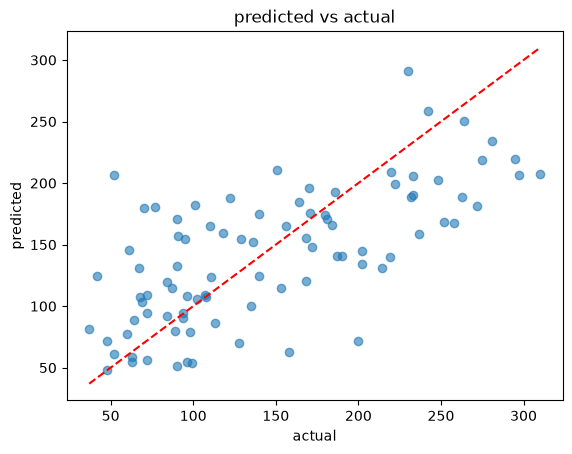

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
# 완벽 예측이면 모든 점이 이 대각선 위에 놓인다
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("predicted vs actual")
plt.show()

In [13]:
coef = pd.Series(model.coef_, index=diabetes.data.columns).sort_values()
print(coef)

s1    -931.488846
sex   -241.964362
age     37.904021
s6      48.670657
s3     163.419983
s4     275.317902
bp     347.703844
s2     518.062277
bmi    542.428759
s5     736.198859
dtype: float64
